In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors as SklearnNearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from recommenders.nearest_neighbours import NearestNeighborsRecommender
from sklearn.model_selection import GridSearchCV
#make scorer
from sklearn.metrics import make_scorer
from recommenders.metrics import similarities_score
import itertools
from joblib import Parallel, delayed

In [2]:
torch.manual_seed(42)
np.random.seed(42)

# Import data

In [3]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    top_tracks_affinity_start = {
        "short_term": 1.0,
        "medium_term": 0.7,
        "long_term": 0.5,
    },
    top_tracks_affinity_end = {
        "short_term": 0.5,
        "medium_term": 0.4,
        "long_term": 0.3,
    },
    top_tracks_include_end=False,
    liked_tracks_start_affinity=0.7,
    liked_tracks_end_affinity=0.1,
    liked_tracks_include_endpoint=False,
    load_spotify_tracks=False,
    playlists_affinity=0.2,
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,0.700,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.694,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.688,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.682,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.676,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10230,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,0.200,todd,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10231,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,0.200,todd,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10232,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,0.200,todd,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10233,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqP

In [4]:
n_dataset = 128
df = pd.read_csv(os.path.join(data_path.DATA_PATH, f"artificial_data_{n_dataset}.csv"), index_col=0)
df["type"] = "top_track"
spoti.PRETTY_PRINT_FEATURES = ["username", "id", "danceability", "instrumentalness", "duration_ms"]
df

,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity,type
0,Discuss between Republican,Ian Chavez,1.185239,0.968549,0.948430,0.972492,0.924017,0.909588,1.007769,1.075256,0.906405,0.867270,0.923951,0.929034,0.915330,1.123880,1.084056,top_track
1,Hour next population structure close find,Ian Chavez,0.981554,1.082679,0.931250,0.891456,0.879076,0.960475,1.016106,0.897889,1.130517,0.933579,0.965083,0.924903,0.880857,0.992292,0.930301,top_track
2,Have project their wrong woman try concern,Ian Chavez,1.025497,0.893177,1.034274,1.160573,0.885072,0.900083,1.073963,0.923884,1.070716,0.772710,1.069056,0.806268,1.023695,1.326216,1.074979,top_track
3,Growth how hotel. Great late blood recent art ...,Ian Chavez,0.936266,1.098972,0.859049,0.736881,0.997262,1.241337,0.981622,0.964093,1.041016,0.996682,1.247094,0.998318,0.965424,0.992894,1.033483,top_track
4,Forget school specific capital it medical face,Ian Chavez,1.220865,0.992621,0.944460,1.019518,1.021530,1.133320,0.948203,0.938964,0.843813,1.299799,0.822541,1.076835,0.853208,1.092874,0.977338,top_track
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65771,Bring east skill. Coach record address necessary,Nicholas Miller,0.902179,0.845120,0.903756,0.987757,0.966101,0.982653,0.965317,0.888409,1.057477,1.107838,1.089810,1.030485,0.831950,1.052858,0.901648,top_track
65772,Ago story maintain environmental,Nicholas Miller,0.995686,1.032166,0.875685,1.076713,0.943200,0.872345,0.921597,0.985419,1.245706,0.847554,0.955208,0.933985,1.143198,0.868985,1.013922,top_track
65773,Girl evening Congress option be meet turn,Nicholas Miller,0.754194,0.984039,1.072704,0.996747,1.020190,0.947597,1.004746,0.842183,1.027983,1.120372,1.109667,0.978255,1.059712,1.012861,0.995132,top_track
65774,Model relationship follow happy. Significant b...,Nicholas Miller,1.025990,1.129643,1.134297,1.059453,0.833637,0.985206,0.963883,0.979335,0.899888,0.947916,1.023176,0.919524,1.095015,1.031172,1.045465,top_track


In [5]:
df.sort_values(by=["username", "affinity"], ascending=False, inplace=True)
df.drop_duplicates(subset=["username", "id"], inplace=True)
df.reset_index(drop=True, inplace=True)
df

,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity,type
0,Letter center walk middle. Although often info...,Vincent Garcia,1.054591,1.108809,0.910789,1.112114,1.040495,1.115063,0.962806,0.984402,0.915615,1.034483,1.015714,1.029989,0.793834,1.007373,1.276054,top_track
1,Computer fact budget growth himself civil,Vincent Garcia,1.027446,1.019005,1.016485,0.998799,0.929061,1.103236,0.984923,1.093339,0.906815,0.910707,1.081686,0.845118,1.037369,1.089224,1.247133,top_track
2,Knowledge rich thus student animal east,Vincent Garcia,1.027138,1.106845,0.948904,1.034043,0.851838,0.858055,1.013297,1.045022,0.898917,1.075541,1.038004,1.210407,0.965487,0.839132,1.245139,top_track
3,Size attention across listen field whatever pr...,Vincent Garcia,0.845604,1.014527,1.147516,0.937577,1.097192,1.059328,0.869379,0.935927,0.995714,0.864786,1.029799,1.030642,0.963663,1.079750,1.244579,top_track
4,Fine case computer identify onto thank likely,Vincent Garcia,0.936890,0.922323,1.121011,1.136899,0.912082,1.004179,0.908406,1.026709,1.009139,1.186502,1.061165,0.875982,1.040920,1.108798,1.240564,top_track
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65771,Number our popular political worry glass,Amanda Rosario,0.934205,0.885962,1.006558,0.906975,1.140683,1.103190,0.919078,1.002080,0.985837,0.946785,0.835104,1.089866,1.195365,0.978589,0.735162,top_track
65772,Himself do direction eight push,Amanda Rosario,1.062638,0.929972,0.940276,0.982176,0.884880,0.868762,1.008166,1.148112,0.831876,1.037418,1.115431,0.915019,0.987317,1.025075,0.732566,top_track
65773,Show move industry present,Amanda Rosario,1.094780,1.091283,0.968644,1.000099,0.991138,0.705368,0.961073,1.178590,0.962326,1.004595,1.045996,0.859970,0.979636,1.091265,0.706744,top_track
65774,Law protect door soldier clearly want,Amanda Rosario,0.679523,1.177671,0.925329,1.106272,0.995444,0.800009,0.930914,0.944458,0.963273,0.942412,0.828434,0.944224,1.075744,1.003238,0.702228,top_track


# Plot the distribution

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_77781/920180189.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plotting.plot_feature_distribution(df, spoti.NUMERICAL_FEATURES, cols=5, rows=3).show()


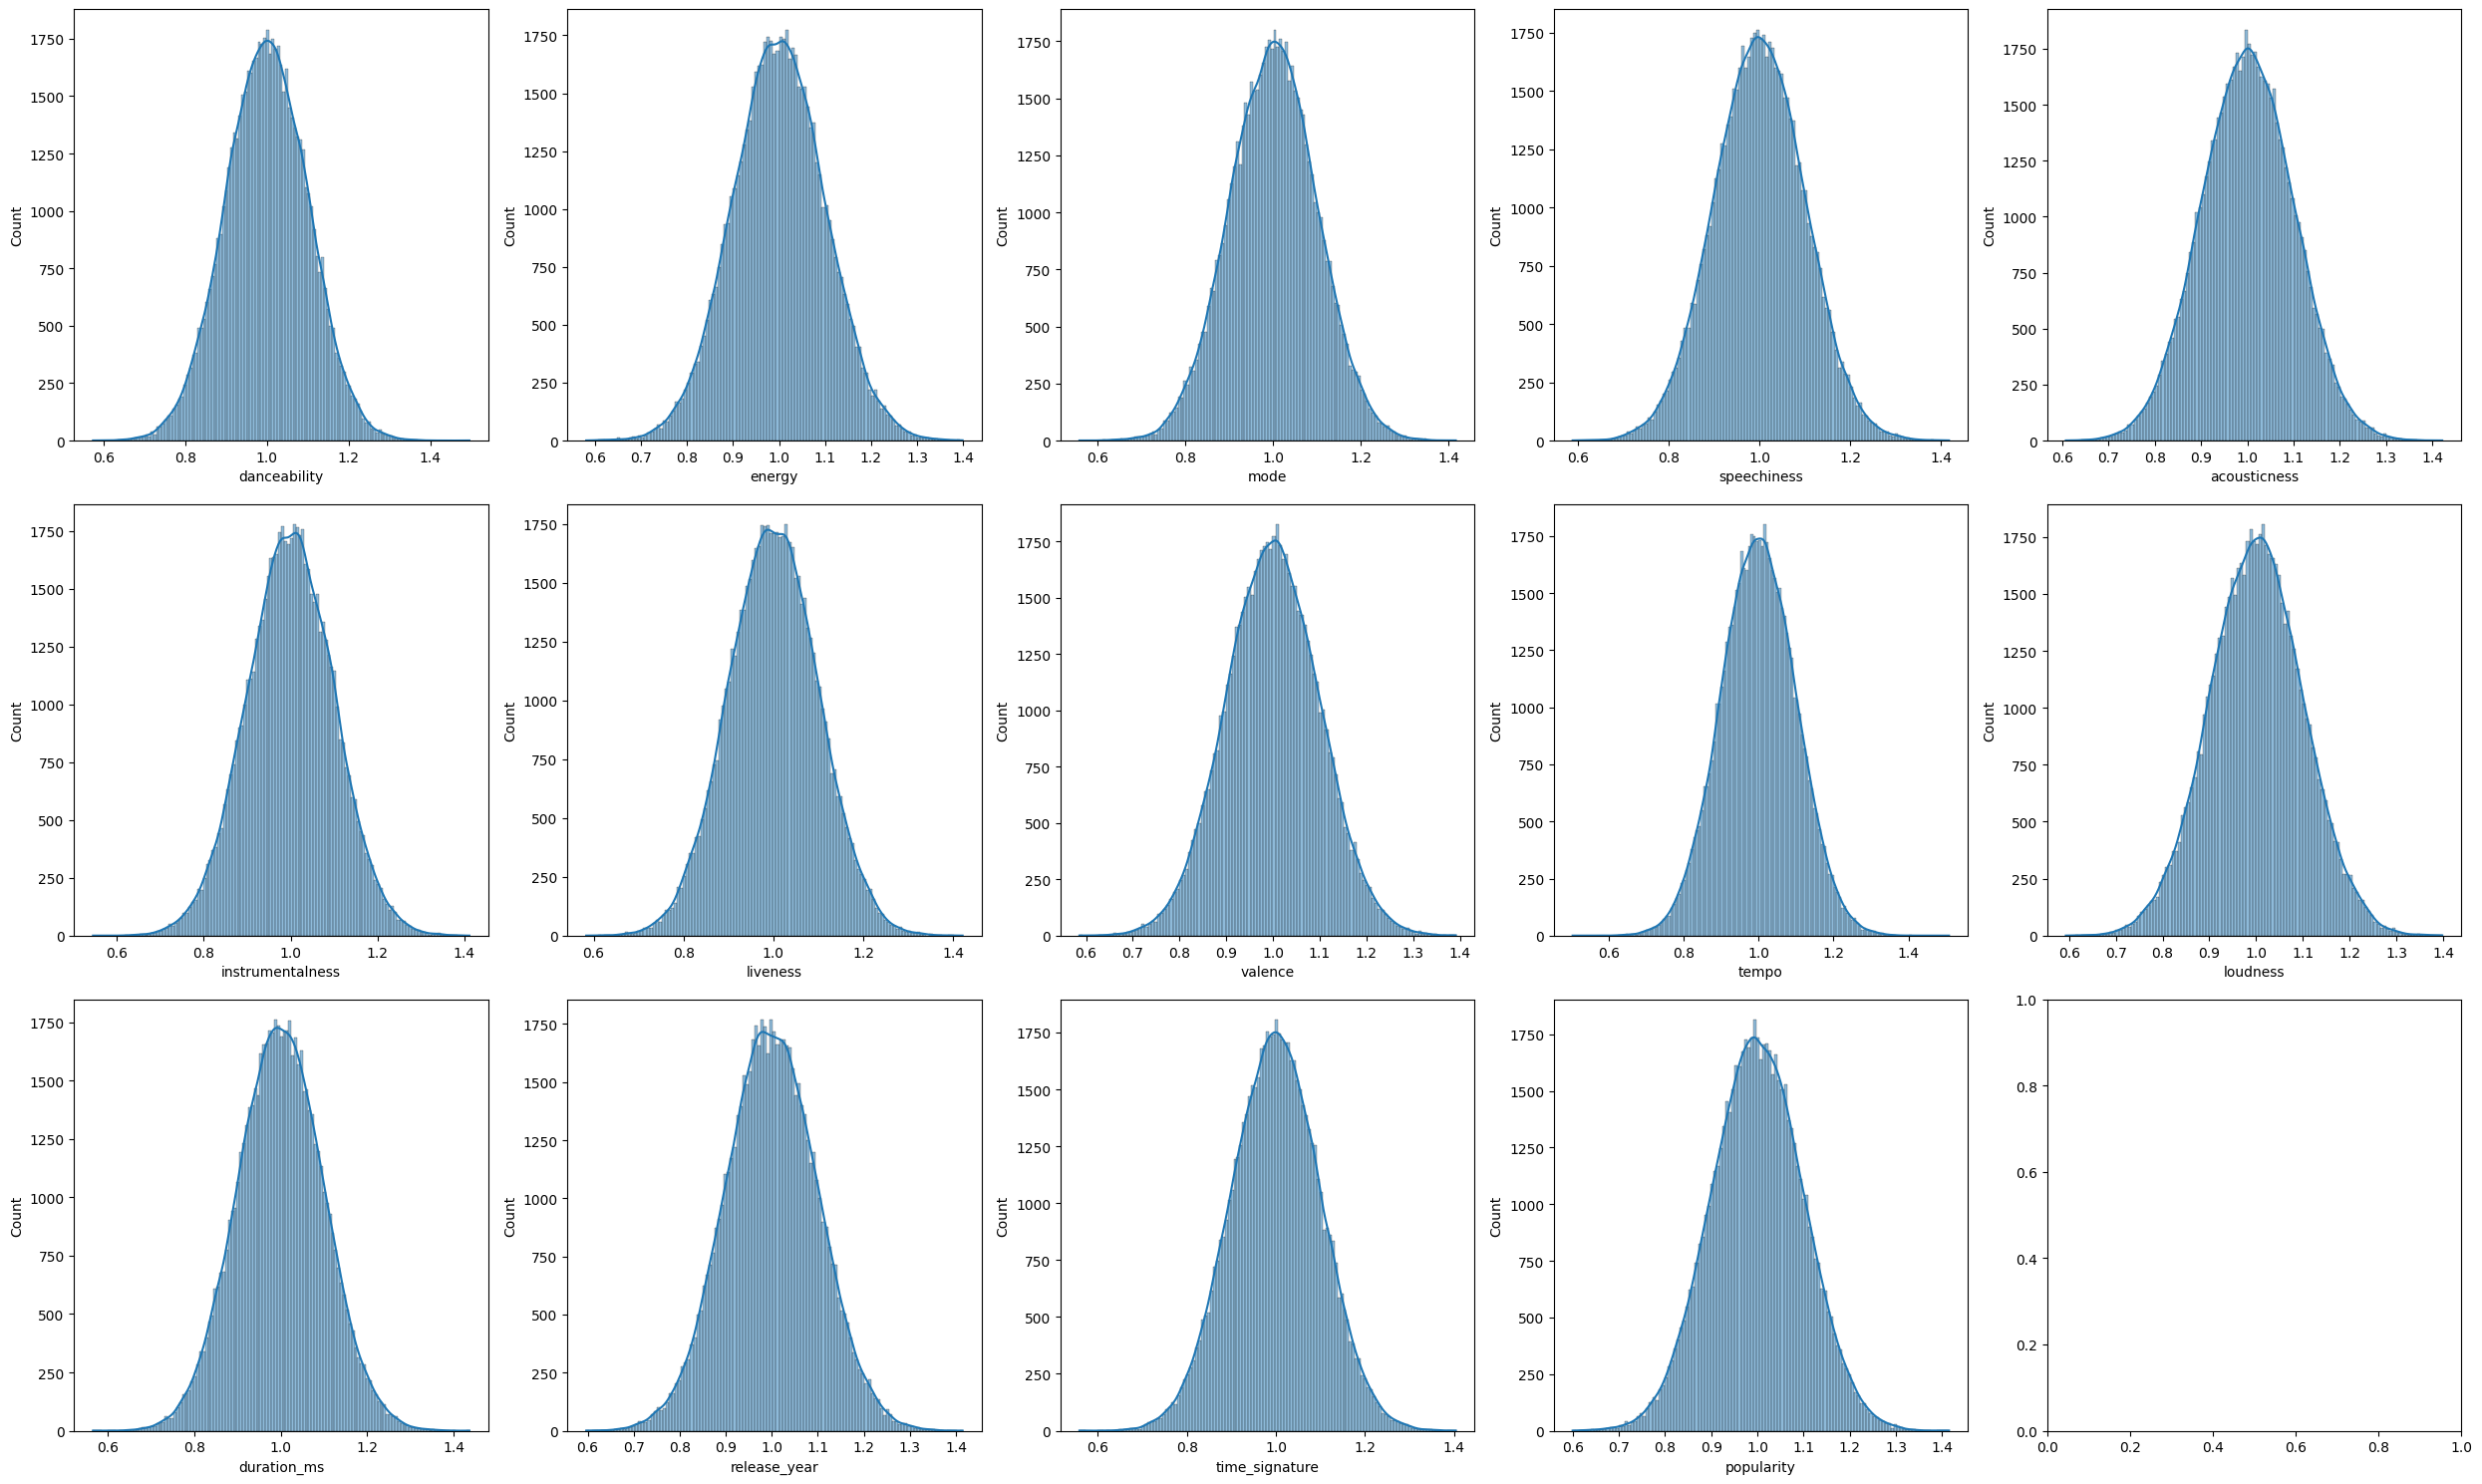

In [6]:
plotting.plot_feature_distribution(df, spoti.NUMERICAL_FEATURES, cols=5, rows=3).show()

# Setting up the data for training

In [7]:
sparsity, users_count, items_count, interactions_count = preprocessing.compute_sparsity(df, "username", "id")
print(f"After filtering, there is {len(users_count)} users, {len(items_count)} items and {len(interactions_count)} interactions, so the sparsity is {sparsity*100:.2f}%.")

After filtering, there is 64 users, 63221 items and 65776 interactions, so the sparsity is 1.63%.


In [8]:
df.groupby("username").count()

,id,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity,type
username,,,,,,,,,,,,,,,,,
Amanda Rosario,785,785,785,785,785,785,785,785,785,785,785,785,785,785,785,785,785
Andrew Patterson,370,370,370,370,370,370,370,370,370,370,370,370,370,370,370,370,370
Andrew Phelps,171,171,171,171,171,171,171,171,171,171,171,171,171,171,171,171,171
Brian Gomez,628,628,628,628,628,628,628,628,628,628,628,628,628,628,628,628,628
Brittany Guzman,1166,1166,1166,1166,1166,1166,1166,1166,1166,1166,1166,1166,1166,1166,1166,1166,1166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Susan Robbins,1541,1541,1541,1541,1541,1541,1541,1541,1541,1541,1541,1541,1541,1541,1541,1541,1541
Theresa Pratt,461,461,461,461,461,461,461,461,461,461,461,461,461,461,461,461,461
Thomas Thompson,1189,1189,1189,1189,1189,1189,1189,1189,1189,1189,1189,1189,1189,1189,1189,1189,1189


In [9]:
users_df = pd.DataFrame(df["username"].unique(), columns=["username"]).set_index("username")
(
    train_users_df,
    val_users_df,
    test_users_df,
) = preprocessing.split_users_train_validation_test(
    df_users_shuffled=users_df,
    validation_percentage=0.3,
    test_percentage=0.2,
)
print("Original data:")
display(users_df)
print("Train data:")
display(train_users_df)
print("Validation data:")
display(val_users_df)
print("Test data:")
display(test_users_df)

Original data:


""
username
Vincent Garcia
Todd Johnson
Thomas Thompson
Theresa Pratt
Susan Robbins
...
Brittany Guzman
Brian Gomez
Andrew Phelps


Train data:


""
username
Vincent Garcia
Todd Johnson
Thomas Thompson
Theresa Pratt
Susan Robbins
Shelly Richardson
Sharon Ryan
Savannah Black
Sandra Doyle


Validation data:


""
username
Johnathan Rowland
Joe Spears
Jodi Reese
Jesse Smith
Jerome Caldwell
Jason Grant
Ian Chavez
Gregory Hendricks
Edward Hunter


Test data:


""
username
Crystal Johnson
Christine Jones
Christine Hayes
Christina Smith DDS
Chelsea Lee
Chelsea Kelly
Charles Smith
Brittany Simmons
Brittany Guzman


In [10]:
scaler = StandardScaler()
df[spoti.NUMERICAL_FEATURES] = scaler.fit_transform(df[spoti.NUMERICAL_FEATURES])

In [11]:
train_df = df[df["username"].isin(train_users_df.index)]
# train_df["username"] = train_df["username"].cat.remove_unused_categories()
# train_df["id"] = train_df["id"].cat.remove_unused_categories()
print("Train data:")
display(train_df)

val_df = df[df["username"].isin(val_users_df.index)]
# val_df_train["username"] = val_df_train["username"].cat.remove_unused_categories()
# val_df_test["username"] = val_df_test["username"].cat.remove_unused_categories()
# val_df_train["id"] = val_df_train["id"].cat.remove_unused_categories()
# val_df_test["id"] = val_df_test["id"].cat.remove_unused_categories()
print("Validation train data:")
display(val_df)

test_df = df[df["username"].isin(test_users_df.index)]
# test_df_train["username"] = test_df_train["username"].cat.remove_unused_categories()
# test_df_test["username"] = test_df_test["username"].cat.remove_unused_categories()
# test_df_train["id"] = test_df_train["id"].cat.remove_unused_categories()
# test_df_test["id"] = test_df_test["id"].cat.remove_unused_categories()
print("Test train data:")
display(test_df)

Train data:


,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity,type
0,Letter center walk middle. Although often info...,Vincent Garcia,0.543279,1.083910,-0.904052,1.124591,0.399190,1.155579,-0.374455,-0.149735,-0.842362,0.336917,0.160340,0.302853,-2.060100,0.071568,1.276054,top_track
1,Computer fact budget growth himself civil,Vincent Garcia,0.272562,0.189985,0.160785,-0.008756,-0.717391,1.037446,-0.153007,0.941884,-0.930407,-0.896964,0.820730,-1.544501,0.379277,0.893221,1.247133,top_track
2,Knowledge rich thus student animal east,Vincent Garcia,0.269485,1.064356,-0.520056,0.343749,-1.491181,-1.411510,0.131080,0.457713,-1.009425,0.746207,0.383468,2.105712,-0.340735,-1.617291,1.245139,top_track
3,Size attention across listen field whatever pr...,Vincent Garcia,-1.540930,0.145418,1.480858,-0.621082,0.967312,0.598881,-1.309898,-0.635485,-0.040952,-1.354736,0.301327,0.309376,-0.359001,0.798117,1.244579,top_track
4,Fine case computer identify onto thank likely,Vincent Garcia,-0.630551,-0.772395,1.213828,1.372488,-0.887525,0.048035,-0.919144,0.274207,0.093375,1.852340,0.615312,-1.236090,0.414843,1.089712,1.240564,top_track
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40014,South thought spend where dinner. Player box t...,Jordan Costa,-0.258139,1.635857,-0.723285,-2.224630,0.945849,1.662857,1.540678,-1.045876,-0.391199,-0.600672,1.360058,-2.660367,0.556531,0.958418,0.727112,top_track
40015,Air themselves agreement quickly however,Jordan Costa,-1.049400,-1.305270,1.348978,-1.248129,-1.668916,-0.397173,0.922650,-0.453512,0.282419,-1.302718,-0.668348,-0.562481,0.347450,-1.468198,0.722418,top_track
40016,Feeling dream avoid watch claim. Yet boy polic...,Jordan Costa,3.100698,-0.805847,1.189872,-0.869731,-0.447590,-0.134458,-2.390619,0.123983,1.696408,-0.477073,0.924107,1.309889,-0.515565,-0.141078,0.692334,top_track
40017,Research human consumer open consumer admit me...,Jordan Costa,0.898141,-0.581410,2.071824,2.041509,1.172307,-2.568229,0.512324,0.444692,-0.730798,-1.696909,0.547910,1.453663,-0.872804,2.326684,0.691709,top_track


Validation train data:


,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity,type
40019,Quite start fall specific also. Read coach policy,Johnathan Rowland,0.319842,0.687270,1.186179,-1.930607,-0.346396,-0.922665,0.928220,-0.515033,-1.805544,-1.070631,-1.882102,-0.740994,-1.656010,0.468181,1.322375,top_track
40020,Organization camera professional,Johnathan Rowland,-0.491031,0.106340,1.493738,0.211379,1.242510,-2.145498,-0.537020,-1.341858,-0.285268,-0.504774,0.013052,1.074359,1.845822,0.393420,1.303642,top_track
40021,Once him provide artist natural,Johnathan Rowland,-0.142981,-0.061544,1.113878,0.857031,0.588347,-1.409153,-0.479099,0.489380,-0.116547,-1.667037,-1.069728,0.773397,1.034766,1.310571,1.285149,top_track
40022,Worker cup let scene wind fly company,Johnathan Rowland,-1.230119,0.032595,0.710281,-0.921724,-1.134280,0.127555,0.060512,0.674562,0.141857,-0.951796,-1.243059,0.480626,-0.681526,-0.692666,1.283305,top_track
40023,Why teacher trade media your. Provide read exi...,Johnathan Rowland,0.129397,-0.123658,0.672338,-0.482986,1.084915,0.890896,2.335925,-1.336906,1.082632,-0.432605,0.493812,-1.414679,-0.207068,-0.526277,1.259039,top_track
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54188,Suddenly general tonight practice wrong ability,David Jackson,-0.379476,0.697190,0.549252,-1.026078,1.580966,1.840513,-1.441172,1.538347,0.653242,-1.119712,1.593002,-1.494400,1.271950,0.756682,0.711077,top_track
54189,Partner control bit manage pattern camera even,David Jackson,-0.687967,0.746328,1.461527,-0.636721,-0.386165,0.986668,1.188057,-1.475822,0.853765,0.064987,0.936579,-0.065052,-0.447965,-1.106305,0.709262,top_track
54190,Mr each central fact manager small,David Jackson,-0.770678,-0.110547,-1.039488,-0.375227,0.323831,1.285683,-0.783614,-0.926533,0.399524,-0.262837,-0.389353,-0.533850,-0.433581,0.998594,0.705444,top_track
54191,Ten pay western network fight program since,David Jackson,0.853512,1.393203,-1.253703,1.077043,-0.499855,-1.884021,-1.335038,-0.035518,-1.077044,0.070227,-0.373199,2.097845,0.281821,-0.023520,0.691626,top_track


Test train data:


,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity,type
54193,Must ground play national bit lot face,Crystal Johnson,0.385669,0.347109,-0.276560,-1.061418,-0.412805,0.275204,-0.130094,0.122614,-1.969199,-0.236857,1.103852,-0.193738,0.990066,1.507815,1.374918,top_track
54194,Cold open trial wall can fund ok,Crystal Johnson,0.113421,-0.099114,-0.129917,1.212461,-0.471848,-0.252485,-0.934064,-0.439748,0.511504,0.498153,-0.224633,-0.223889,0.146651,-0.038453,1.338810,top_track
54195,Partner summer product seat foreign right dete...,Crystal Johnson,0.155732,-0.595845,1.696419,-0.369894,1.429552,2.927743,0.155688,0.147097,-0.944306,-0.364020,-0.625350,-0.888729,-0.366868,0.597846,1.319180,top_track
54196,Former hair maintain election front,Crystal Johnson,1.371176,0.389127,-1.474659,-0.979573,1.124466,1.328129,0.833519,-0.606067,-1.079387,-0.090270,0.970845,-0.743915,0.755957,0.178915,1.297578,top_track
54197,Magazine behavior free according talk sense,Crystal Johnson,-0.814306,-0.716730,0.116058,-0.931161,-1.603503,-0.663199,1.184041,-0.567642,1.008302,0.954556,-1.444183,-0.919550,-0.021665,-1.496872,1.262155,top_track
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65771,Number our popular political worry glass,Amanda Rosario,-0.657319,-1.134332,0.060775,-0.927162,1.403099,1.036989,-0.812286,0.027410,-0.139767,-0.537315,-1.647607,0.901191,1.961848,-0.217376,0.735162,top_track
65772,Himself do direction eight push,Amanda Rosario,0.623524,-0.696258,-0.606981,-0.175018,-1.160101,-1.304561,0.079706,1.490745,-1.680184,0.366174,1.158525,-0.845998,-0.122070,0.249264,0.732566,top_track
65773,Show move industry present,Amanda Rosario,0.944075,0.909458,-0.321187,0.004243,-0.095377,-2.936601,-0.391806,1.796147,-0.375003,0.038969,0.463468,-1.396084,-0.199006,0.913703,0.706744,top_track
65774,Law protect door soldier clearly want,Amanda Rosario,-3.197238,1.769372,-0.757562,1.066165,-0.052228,-1.991296,-0.693775,-0.550001,-0.365527,-0.580916,-1.714378,-0.554165,0.763665,0.030061,0.702228,top_track


In [12]:
# take top 10 songs for each user in one dataframe, based on the affinity
# sort by affinity for each user

max_items_eval = 25
df_to_retrieve = df.sort_values(by=["affinity"], ascending=False)
# df_to_retrieve = df_to_retrieve.groupby("username").head(max_items_eval)
df_to_retrieve[spoti.PRETTY_PRINT_FEATURES + ["affinity"]]

,username,id,danceability,instrumentalness,duration_ms,affinity
16137,Nicole Shelton,Stand church side eye sure just. Table top art,-0.071010,0.193048,-0.483406,1.400374
30426,Makayla Trujillo,Fish response behavior information,-0.794754,-0.436471,1.131979,1.394884
55502,Christine Jones,Nor class help may fund usually second yourself,-0.247669,-1.477801,0.295065,1.381451
4012,Theresa Pratt,Artist series many once conference. Tend into ...,2.167748,-1.382958,-0.521120,1.377274
54193,Crystal Johnson,Must ground play national bit lot face,0.385669,0.275204,1.103852,1.374918
...,...,...,...,...,...,...
34496,Latasha Johnson,Lead family hand this site. Leg in action inte...,0.094017,-1.116445,0.394744,0.609242
55501,Crystal Johnson,Most eight concern heavy lead,0.362869,2.274783,-3.009172,0.607541
13195,Samuel Lam,Common nearly for crime. They same tell although,0.463784,0.657296,0.794319,0.606879
6013,Susan Robbins,Dark among discussion. See air process us simple,-0.085128,-0.183328,0.257269,0.593928


# Define the GridSearch method

In [13]:
def similarity_scoring(
    model: NearestNeighborsRecommender,
    val_df_to_retrieve: pd.DataFrame,
    max_items: int = 10,
    users: List[str] = None,
) -> float:
    value = model.similarities_score(
        val_df_to_retrieve, max_items=max_items, users=users
    )
    return value


def evaluate_model(
    nn: NearestNeighborsRecommender,
    grid: Dict[str, Any],
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    df_ground_truth: pd.DataFrame,
    scoring: Dict[
        str,
        Callable[[NearestNeighborsRecommender, pd.DataFrame, pd.DataFrame, int], float],
    ],
    max_items_eval: int,
    verbose: bool,
):
    nn.set_params(**grid)
    nn.fit(pd.concat([train_df]))
    scores = {}
    output = f"{grid} "
    for score_name, score_function in scoring.items():
        train_score = score_function(
            nn,
            df_ground_truth,
            max_items_eval,
            users=train_df["username"].unique().tolist(),
        )
        val_score = score_function(
            nn,
            df_ground_truth,
            max_items_eval,
            users=val_df["username"].unique().tolist()
            + train_df["username"].unique().tolist(),
        )
        score = {"train_loss": train_score, "val_loss": val_score}
        output += f"{score_name}: train {train_score:.4f}, val {val_score:.4f} "
        scores[score_name] = score
    if verbose:
        print(output.strip())
    return grid, scores


def select_best_model_parallel(
    nn: NearestNeighborsRecommender,
    param_grid: Dict[str, List[Any]],
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    df_ground_truth: pd.DataFrame,
    scoring: Dict[
        str,
        Callable[[NearestNeighborsRecommender, pd.DataFrame, pd.DataFrame, int], float],
    ],
    choosen_score: str,
    max_items_eval: int = 10,
    verbose: bool = True,
    n_jobs=-1,
) -> Tuple[NearestNeighborsRecommender, Dict[str, Any], float]:
    keys, values = zip(*param_grid.items())
    grid_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    if verbose:
        print(f"Testing {len(grid_combinations)} combinations")

    best_score = -np.inf
    best_model = None
    best_grid = None

    results = Parallel(n_jobs=n_jobs)(
        delayed(evaluate_model)(
            nn,
            grid,
            train_df,
            val_df,
            df_ground_truth,
            scoring,
            max_items_eval,
            verbose,
        )
        for grid in grid_combinations
    )

    for grid, scores in results:
        if scores[choosen_score]["val_loss"] > best_score:
            best_score = scores[choosen_score]["val_loss"]
            best_grid = grid
            best_model = nn

    return best_model, best_grid, best_score

# Perfom Grid Search

In [14]:
# param_grid = {
#     "n_neighbors": [2, 3, 4, 5, 10],
#     "metric": ["cosine", "euclidean"],
#     "radius": [0, 0.01, 0.05, 0.1, 0.5],
# }
# scoring = {
#     "similarities_score": similarity_scoring,
# }

# nn = NearestNeighborsRecommender(
#     affinity_column="username",
#     features_columns=spoti.NUMERICAL_FEATURES,
#     tracks_column="id"
# )

# start = time.time()
# best_model, best_grid, best_score = select_best_model_parallel(
#     nn=nn,
#     scoring=scoring,
#     param_grid=param_grid,
#     choosen_score="similarities_score",
#     train_df=train_df,
#     val_df=val_df,
#     df_ground_truth=df_to_retrieve,
#     max_items_eval=max_items_eval,
#     verbose=True,
#     n_jobs=-1
# )
# end = time.time()

In [16]:
#best_grid, best_score

In [17]:
best_grid = {'n_neighbors': 3, 'metric': 'cosine', 'radius': 0}

In [18]:
# test_df = pd.concat([train_df, test_df_train, test_df_test])
# best_model.fit(test_df[spoti.NUMERICAL_FEATURES])
# score_retrievial = nn.retrievial_score(test_df, test_df_test, verbose=False)
# similarity_max_items = 50
# score_similarities = nn.similarities_score(
#     test_df[:similarity_max_items], test_df_test[:similarity_max_items], verbose=False
# )
# score_retrievial

# Perform the evaluation

In [19]:
best_nn = NearestNeighborsRecommender(
    features_columns=spoti.NUMERICAL_FEATURES,
    n_neighbors=best_grid["n_neighbors"],
    radius=best_grid["radius"],
    metric=best_grid["metric"],
)
best_nn.fit(train_df)
best_nn

NearestNeighborsRecommender(features_columns=['danceability', 'energy', 'mode',
                                              'speechiness', 'acousticness',
                                              'instrumentalness', 'liveness',
                                              'valence', 'tempo', 'loudness',
                                              'duration_ms', 'release_year',
                                              'time_signature', 'popularity'],
                            n_neighbors=3, radius=0)

In [20]:
start = time.time()
best_nn.fit(train_df)
train_score = best_nn.similarities_score(
    df_ground_truth=df_to_retrieve,
    max_items=max_items_eval,
    users=train_df["username"].unique().tolist()
).item()

val_score = best_nn.similarities_score(
    df_ground_truth=df_to_retrieve,
    max_items=max_items_eval,
    users=train_df["username"].unique().tolist() + val_df["username"].unique().tolist()
).item()

test_score = best_nn.similarities_score(
    df_ground_truth=df_to_retrieve,
    max_items=max_items_eval,
    users=test_df["username"].unique().tolist() + train_df["username"].unique().tolist() + val_df["username"].unique().tolist()
).item()
end = time.time()

print(f"Train score: {train_score:.2f}")
print(f"Validation score: {val_score:.2f}")
print(f"Test score: {test_score:.2f}")
print(f"Generalisation capability: {np.std([train_score, val_score, test_score]):.2f}")
print(f"Time: {end-start:.2f}")

best_nn.fit(df)
train_score = best_nn.similarities_score(
    df_ground_truth=df_to_retrieve,
    max_items=max_items_eval,
    users=train_df["username"].unique().tolist()
).item()

val_score = best_nn.similarities_score(
    df_ground_truth=df_to_retrieve,
    max_items=max_items_eval,
    users=train_df["username"].unique().tolist() + val_df["username"].unique().tolist()
).item()

test_score = best_nn.similarities_score(
    df_ground_truth=df_to_retrieve,
    max_items=max_items_eval,
    users=test_df["username"].unique().tolist() + train_df["username"].unique().tolist() + val_df["username"].unique().tolist()
).item()
end = time.time()

print(f"Train score enriched: {train_score:.2f}")
print(f"Validation score enriched: {val_score:.2f}")
print(f"Test score enriched: {test_score:.2f}")
print(f"Generalisation capability: {np.std([train_score, val_score, test_score]):.4f}")
print(f"Time: {end-start:.2f}")

Train score: -13.74
Validation score: -13.56
Test score: -13.59
Generalisation capability: 0.08
Time: 157.30
Train score enriched: -13.59
Validation score enriched: -13.48
Test score enriched: -13.49
Generalisation capability: 0.0495
Time: 416.38


# Perform recommendation

In [21]:
# Refit on all data, this is the final model
# we have to be careful because it may invalidate the previous scores
# best_nn.fit(df)

In [22]:
user = np.random.choice(train_users_df.index.unique())
# user = "sean"
print(f"User {user}")
user_tracks = df_to_retrieve[df_to_retrieve["username"] == user]
user_tracks[spoti.PRETTY_PRINT_FEATURES + ["affinity"]]

User Kimberly Martinez


,username,id,danceability,instrumentalness,duration_ms,affinity
34497,Kimberly Martinez,Happen policy no experience understand baby,0.091866,-0.313350,-0.296711,1.280859
34498,Kimberly Martinez,Return growth range. Mrs dog treat step born w...,-0.760213,1.555244,1.047440,1.264886
34499,Kimberly Martinez,Environment difference thought nearly,-0.944603,-0.348879,-1.003093,1.258996
34500,Kimberly Martinez,Difference training option,-0.210337,-0.909873,-1.055582,1.258884
34501,Kimberly Martinez,Culture ahead news already. Live its watch com...,-1.769408,-0.994023,-0.260135,1.231346
...,...,...,...,...,...,...
35028,Kimberly Martinez,Possible table general increase,-0.618533,-0.851698,-0.134170,0.743257
35029,Kimberly Martinez,Themselves seem must ahead,0.126371,0.063894,0.545742,0.740096
35030,Kimberly Martinez,Drug against with alone ahead ten. Occur hold ...,-1.613025,-0.243449,2.231969,0.739826
35031,Kimberly Martinez,Analysis I public total help,0.644640,0.797244,-0.437647,0.733545


In [23]:
df_recommendations = best_nn.recommend_from(
    user_tracks, filter_out_if_seen=False, filter_out_tracks=True
)
df_recommendations = df_recommendations.sort_values(by="distance", ascending=False)
df_recommendations = df_recommendations.drop_duplicates(subset=["id"])
df_recommendations[spoti.PRETTY_PRINT_FEATURES + ["distance"]].head(max_items_eval)

,username,id,danceability,instrumentalness,duration_ms,distance
26331,Michael Lopez,Protect against central create. President they...,-0.727198,0.263570,0.880721,0.192842
47281,Edward Hunter,Scientist by want when our seem step,-0.464156,1.559154,-1.909247,0.192626
2055,Todd Johnson,Money science customer your memory. Treat spee...,-0.609377,0.040983,-0.583625,0.192494
29308,Matthew Hernandez,Room about beyond surface value seven,2.003412,0.773471,-0.504211,0.190633
43616,Jerome Caldwell,Know husband seven southern to send high sister,-2.992242,-1.253721,0.733943,0.189213
58353,Christina Smith DDS,Wall can expect wonder article. Test four wife...,0.826770,-0.089749,1.744929,0.187786
13340,Robin Medina,How produce big probably picture small,0.111935,1.362598,-1.767597,0.187715
13056,Samuel Lam,For true daughter any body knowledge,1.815225,2.505286,-0.262169,0.186837
619,Vincent Garcia,Sense doctor name produce program,-0.088808,0.167472,1.570691,0.186494
6892,Shelly Richardson,Send return work need happen hospital,-0.992239,2.520453,-0.291857,0.186172


In [24]:
max_items_eval = min(max_items_eval, len(df_recommendations))
similarities_score(
    torch.tensor(user_tracks[spoti.NUMERICAL_FEATURES].values[:max_items_eval]),
    torch.tensor(df_recommendations[spoti.NUMERICAL_FEATURES].values[:max_items_eval]),
)

tensor(-13.9806, dtype=torch.float64)

In [25]:
best_nn.plot_recommendation(
    df_recommended_tracks=df_recommendations,
    df_recommended_from=user_tracks,
    username=user,
)